Avances 26/Dic/2025
El marco correcto de acción para este proyecto es que estoy midiendo una clase de distancia entre 2 sistemas. A que me refiero? Vamos a plantearlo de la manera mas sencilla posible que nos pueda ayudar a entender con lo que estoy lidiando

Tenemos 2 distribuciones de probabilidad, la dada cuando el sistema le aplicamos medidas Fuzzy, y la dada cuando no. Queremos encontrar una medida que nos permita cuantificar matemáticamente la perdida de información por el error y relacionarla con la probabilidad de error y acierto del mismo. Este es el eje central de este asunto



Hasta ahora habiamos visualizado 2 herramientas para tajar este problema: La fidelidad cuántica y la Información Mutua. Sin embargo, tienen 2 problemas:

La fidelidad no nos da una buena relación entre la probabilidad de error y éxito del algoritmo

La información mutua REQUIERE de conocer no solo las distribuciones de probabilidad marginales, si no las distribuciones de probabilidad conjuntas del sistema, algo que no existe como tal porque aunque son similares. Son independientes

En nuestro problema tenemos 2 Distribuciones de probabilidad: X y Y. X es la distribución de probabilidad del algoritmo de order finding en el registro Ancilla tras correr el algoritmo sin errores. Y es la distribución de probabilidad del mismo algoritmo pero tras aplicar las Fuzzy measurments 

Aqui propondremos algunas métricas que podriamos utilizar para poder realizar la medición de la distancia entre las 2 distribuciones de probabilidad. 


Sean $X$ y $Y$ dos variables aleatorias discretas definidas sobre el mismo espacio de valores
$$
\mathcal{X} = \{0,1,\dots,N\},
$$
con distribuciones de probabilidad
$$
P(x) = \mathbb{P}(X=x),
\qquad
Q(x) = \mathbb{P}(Y=x),
$$
tales que
$$
P(x)\ge 0,\quad Q(x)\ge 0,
\qquad
\sum_{x\in\mathcal{X}} P(x) = \sum_{x\in\mathcal{X}} Q(x) = 1.
$$

El objetivo es cuantificar matemáticamente qué tan diferentes son las distribuciones de $X$ y $Y$.

Definamos la métrica entre distribuciones de probabilidad

Una función
$$
d(P,Q)
$$
es una métrica entre distribuciones si satisface:


No negatividad:
$$
d(P,Q)\ge 0
$$
Identidad:
$$
d(P,Q)=0 \iff P=Q
$$
Simetría:
$$
d(P,Q)=d(Q,P)
$$
Desigualdad triangular:
$$
d(P,R)\le d(P,Q)+d(Q,R)
$$

Veamos varias. 

--Distancia de variación total

La distancia de variación total se define como
$$
\mathrm{TV}(P,Q)
=
\frac{1}{2}\sum_{x\in\mathcal{X}} \left| P(x)-Q(x) \right|.
$$

Esta cantidad mide la máxima diferencia posible entre las probabilidades asignadas por las distribuciones $P$ y $Q$ a cualquier evento del espacio de resultados. De manera equivalente, la distancia de variación total puede definirse de forma operativa como
$$
\mathrm{TV}(P,Q)
=
\sup_{A \subseteq \mathcal{X}}
\left| P(A) - Q(A) \right|,
$$
donde $P(A)=\sum_{x\in A}P(x)$ y $Q(A)=\sum_{x\in A}Q(x)$.

En el contexto del algoritmo de order finding, la probabilidad de éxito se define como la probabilidad que la distribución inducida por el algoritmo asigna al conjunto de valores de éxito $Y_{\mathrm{ex}}$. Si $P$ denota la distribución ideal de los resultados de medición y $Q$ la distribución obtenida en presencia de ruido, la pérdida de probabilidad de éxito puede escribirse como
$$
\left| P_{\mathrm{ex}}(Q) - P_{\mathrm{ex}}(P) \right|
=
\left| Q(Y_{\mathrm{ex}}) - P(Y_{\mathrm{ex}}) \right|.
$$

Dado que $Y_{\mathrm{ex}}$ es un evento particular del espacio de resultados, por definición de la distancia de variación total se cumple que
$$
\left| Q(Y_{\mathrm{ex}}) - P(Y_{\mathrm{ex}}) \right|
\le
\mathrm{TV}(P,Q).
$$

Por lo tanto, la distancia de variación total proporciona una cota superior directa para la posible degradación de la probabilidad de éxito del algoritmo. En particular, si $\mathrm{TV}(P,Q)$ es pequeña, la probabilidad de éxito del algoritmo bajo ruido no puede diferir significativamente de la probabilidad de éxito ideal, lo que permite interpretar a $\mathrm{TV}(P,Q)$ como una medida operativa de la robustez del algoritmo frente a perturbaciones que modifican la distribución de probabilidad de los resultados de medición.



-Distancia de Hellinger

La distancia de Hellinger se define como
$$
H^2(P,Q)
=
\frac{1}{2}
\sum_{x\in\mathcal{X}}
\left(\sqrt{P(x)}-\sqrt{Q(x)}\right)^2.
$$

Esta cantidad mide la distancia geométrica entre las distribuciones asociadas a $X$ y $Y$.




--Divergencia de Jensen--Shannon

Se define la distribución promedio
$$
M(x)=\frac{1}{2}\big(P(x)+Q(x)\big).
$$

La divergencia de Jensen--Shannon está dada por
$$
\mathrm{JS}(P\|Q)
=
\frac{1}{2}\sum_x P(x)\log\frac{P(x)}{M(x)}
+
\frac{1}{2}\sum_x Q(x)\log\frac{Q(x)}{M(x)}.
$$

Esta divergencia mide qué tan distinguibles son las distribuciones de $X$ y $Y$ como fuentes de información. En particular, cuantifica cuánta información se obtiene, en promedio, al observar una muestra y tratar de inferir si fue generada por la distribución $P$ o por la distribución $Q$, asumiendo que ambas son igualmente probables.

La divergencia de Jensen--Shannon está estrechamente relacionada con la divergencia de Kullback--Leibler, definida como
$$
D_{\mathrm{KL}}(P\|Q)
=
\sum_x P(x)\log\frac{P(x)}{Q(x)}.
$$

Desde la teoría de la información, la divergencia de Kullback--Leibler mide la pérdida de eficiencia al codificar datos generados por una fuente $P$ utilizando un código óptimo para una fuente $Q$. Sin embargo, $D_{\mathrm{KL}}$ no es simétrica y puede divergir cuando $Q(x)=0$ y $P(x)>0$, lo que la hace poco adecuada para comparar distribuciones empíricas o ruidosas.

La divergencia de Jensen--Shannon puede interpretarse como una versión regularizada y simétrica de la divergencia de Kullback--Leibler, ya que compara cada distribución con la mezcla $M$, garantizando finitud y estabilidad. Además, puede expresarse en términos de entropía de Shannon como
$$
\mathrm{JS}(P\|Q)
=
H(M)
-
\frac{1}{2}H(P)
-
\frac{1}{2}H(Q),
$$
donde
$$
H(P) = -\sum_x P(x)\log P(x)
$$
es la entropía de Shannon.

Esta expresión muestra que la divergencia de Jensen--Shannon mide el aumento de incertidumbre asociado a mezclar dos fuentes distintas. En este sentido, $\mathrm{JS}(P\|Q)$ tiene una interpretación informacional clara y puede entenderse como una información mutua bien definida entre la fuente que genera los datos y la observación, incluso cuando no se dispone de una distribución conjunta entre las variables aleatorias.

La relación entre la divergencia de Jensen--Shannon y la distancia de variación total se establece mediante la desigualdad de Pinsker, la cual conecta medidas informacionales con medidas operativas de distinguibilidad entre distribuciones. En particular, dicha desigualdad implica que la distancia de variación total entre dos distribuciones puede acotarse superiormente en términos de su divergencia de Jensen--Shannon.

De forma explícita, se cumple que
$$
\mathrm{TV}(P,Q)
\le
\sqrt{2\,\mathrm{JS}(P\|Q)},
$$
cuando la divergencia de Jensen--Shannon se define utilizando logaritmos naturales. Si se emplean logaritmos en base $2$, esta relación toma la forma
$$
\mathrm{TV}(P,Q)
\le
\sqrt{2\ln 2\;\mathrm{JS}(P\|Q)}.
$$

Esta desigualdad muestra que una divergencia de Jensen--Shannon pequeña garantiza que las distribuciones $P$ y $Q$ son cercanas en el sentido de la distancia de variación total. En consecuencia, no existe ningún evento cuya probabilidad pueda diferir significativamente entre ambas distribuciones.

En el contexto del algoritmo de \order finding, donde la probabilidad de éxito está asociada a un conjunto fijo de valores de éxito, esta relación permite acotar directamente la posible pérdida de probabilidad de éxito en términos de la divergencia de Jensen--Shannon. De este modo, $\mathrm{JS}(P\|Q)$ proporciona una medida informacional que controla la estabilidad del rendimiento del algoritmo frente a perturbaciones que modifican la distribución de probabilidad de los resultados de medición.
Además de su interpretación informacional, la divergencia de Jensen--Shannon está directamente relacionada con la distancia de variación total entre distribuciones de probabilidad. En particular, la distancia de variación total entre $P$ y $Q$ se define como
$$
\mathrm{TV}(P,Q)
=
\sup_{A\subseteq\mathcal{X}} |P(A)-Q(A)|,
$$
y cuantifica el mayor cambio posible en probabilidad que cualquier evento puede experimentar al pasar de la distribución $P$ a la distribución $Q$.

La conexión entre la divergencia de Jensen--Shannon y la distancia de variación total se establece a través de la desigualdad de Pinsker, la cual proporciona una cota superior para $\mathrm{TV}(P,Q)$ en términos de una divergencia basada en Kullback--Leibler. Aplicada a la divergencia de Jensen--Shannon, esta relación toma la forma
$$
\mathrm{TV}(P,Q)
\le
\sqrt{2\ln 2 \; \mathrm{JS}(P\|Q)},
$$
cuando la divergencia de Jensen--Shannon se mide en bits.

Esta desigualdad muestra que una divergencia de Jensen--Shannon pequeña implica necesariamente que las distribuciones $P$ y $Q$ están cercanas en el sentido de variación total. En consecuencia, ninguna probabilidad asociada a un evento fijo puede cambiar de manera significativa al pasar de $P$ a $Q$.

En el contexto del algoritmo de \emph{order finding}, donde la probabilidad de éxito se define como la masa de probabilidad asignada al conjunto de valores de éxito $Y_{\mathrm{ex}}$, la desigualdad anterior implica que la posible degradación de la probabilidad de éxito está controlada por la divergencia de Jensen--Shannon entre las distribuciones inducidas por el algoritmo ideal y por el algoritmo bajo ruido. De este modo, la divergencia de Jensen--Shannon actúa como un certificado informacional de estabilidad del algoritmo frente a perturbaciones que modifican la distribución de los resultados de medición.



Programaré las 3 distancias y las pondre a prueba para distintos modelos de error del sistema

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import math
from fractions import Fraction




def graficar_probabilidades(probs, 
                            titulo="Amplitudes de probabilidad", 
                            tipo_etiqueta="bin", 
                            etiquetas_personalizadas=None,
                            rango=None,
                            ys_exitosos=None):

    probs = np.array(probs, dtype=float)
    if not np.isclose(np.sum(probs), 1):
        probs = probs / np.sum(probs)

    n_total = len(probs)
    x_total = np.arange(n_total)

    # --- Generación de etiquetas 
    if tipo_etiqueta == "num":
        etiquetas_total = [str(i) for i in range(n_total)]

    elif tipo_etiqueta == "bin":
        k = max(1, math.ceil(math.log2(n_total)))
        etiquetas_total = [format(i, f"0{k}b") for i in range(n_total)]

    else:
        raise ValueError("tipo_etiqueta debe ser 'num' o 'bin'")

    # --- Aplicar rango ---
    if rango is not None:
        inicio, fin = rango
        if not (0 <= inicio < fin <= n_total):
            raise ValueError(f"Rango inválido: debe estar dentro de [0, {n_total})")
        probs = probs[inicio:fin]
        x = np.arange(inicio, fin)
        etiquetas = etiquetas_total[inicio:fin]
    else:
        x = x_total
        etiquetas = etiquetas_total

    n = len(probs)

    # --- Colores personalizados si ys_exitosos está definido ---
    if ys_exitosos is not None:
        colors = ["red" if i in ys_exitosos else "steelblue" for i in x]
    else:
        colors = "steelblue"

    # --- Ajustes automáticos ---
    ancho_figura = max(8, n * 0.25)
    rotacion_etiquetas = 90 if n > 16 else 45 if n > 8 else 0
    if n > 512:
        fontsize_etiquetas = 8
    elif n > 128:
        fontsize_etiquetas = 10
    elif n > 32:
        fontsize_etiquetas = 12
    else:
        fontsize_etiquetas = 14

    # --- Graficar ---
    plt.figure(figsize=(ancho_figura, 5))
    plt.bar(x, probs, width=0.8, color=colors)
    plt.xticks(x, etiquetas, rotation=rotacion_etiquetas, fontsize=fontsize_etiquetas)
    plt.ylabel("Probabilidad", fontsize=14)
    plt.title(titulo, fontsize=16)
    plt.ylim(0, max(probs) * 1.1)
    plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()

In [3]:
def total_variation_distance(P, Q):
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float) #Codifica los arrays como numpy arrays de tipo float
    return 0.5 * np.sum(np.abs(P - Q))

def hellinger_distance(P, Q):
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)
    return np.sqrt(0.5 * np.sum((np.sqrt(P) - np.sqrt(Q))**2))

def jensen_shannon_divergence(P, Q, base=2):
    P = np.asarray(P, dtype=float)
    Q = np.asarray(Q, dtype=float)

    M = 0.5 * (P + Q)

    def kl_divergence(A, B):
        mask = A > 0
        return np.sum(A[mask] * np.log(A[mask] / B[mask]))

    js = 0.5 * kl_divergence(P, M) + 0.5 * kl_divergence(Q, M)

    if base == 2:
        js /= np.log(2)
    elif base == 10:
        js /= np.log(10)

    return js

def probs_teoricas_QPE_l(r, l):
    Q = 2**l  # tamaño del registro ancilla
    q = Q // r
    c = Q % r
    Q0 = r * q
    
    probs = np.zeros(Q, dtype=float)
    
    for y in range(Q):
        if (r * y) % Q != 0:  # caso general
            num = (
                c * np.sin(np.pi * r * y / Q * (Q0 / r + 1))**2
                + (r - c) * np.sin(np.pi * r * y / Q * (Q0 / r))**2
            )
            den = (Q**2) * (np.sin(np.pi * r * y / Q)**2)
            probs[y] = num / den if den != 0 else 0.0
        else:  # caso múltiplo exacto
            probs[y] = (
                c * (Q0 + r)**2 + (r - c) * (Q0**2)
            ) / (Q**2 * r**2)
    
    return probs

In [4]:
def U_swap(n, a, b):

    if not (0 <= a < n) or not (0 <= b < n):
        raise ValueError("Los índices de qubits deben cumplir 0 <= a,b < n.")
    if a == b:
        raise ValueError("a y b deben ser qubits distintos.")

    dim = 1 << n  # 2**n
    U = np.zeros((dim, dim), dtype=complex)

    # Convertimos de índice físico a posición en el entero (LSB indexing)
    j1 = n - 1 - a
    j2 = n - 1 - b

    for i in range(dim):
        # extraer bit j1 y j2
        b1 = (i >> j1) & 1
        b2 = (i >> j2) & 1

        if b1 == b2:
            j = i  # no cambia nada si los bits son iguales
        else:
            # flip de ambos bits
            j = i ^ (1 << j1) ^ (1 << j2)

        U[j, i] = 1.0

    return U



def U_swap_circular(l):
    U = np.eye(2**l, dtype=complex)
    for k in range(l-1):
        U = U_swap(l, k, k+1) @ U
    return U


def U_swap_circular_k(l, k):
    k = k % l  # rotaciones equivalentes mod l
    U = np.eye(2**l, dtype=complex)
    if k == 0:
        return U
    U1 = U_swap_circular(l)
    for _ in range(k):
        U = U1 @ U
    return U


def U_swap_all_pairs(n):
    """
    Aplica SWAP en todas las parejas de qubits adyacentes:
    (0<->1), (2<->3), (4<->5), ...
    """
    if n % 2 != 0:
        raise ValueError("Para intercambiar todas las parejas, n debe ser par.")
    
    U = np.eye(2**n, dtype=complex)
    for k in range(0, n, 2):
        U = U_swap_adjacent(n, k) @ U
    return U

def U_swap_adjacent(n, k):
    if not (0 <= k < n-1):
        raise ValueError("k debe cumplir 0 <= k < n-1.")

    dim = 1 << n  # 2**n
    U = np.zeros((dim, dim), dtype=complex)

    # En esta convención, el bit físico k (MSB indexing) está en posición LSB j1 = n-1-k.
    j1 = n - 1 - k
    j2 = n - 1 - (k + 1)

    for i in range(dim):
        # extrae bits
        b1 = (i >> j1) & 1
        b2 = (i >> j2) & 1
        if b1 == b2:
            j = i
        else:
            # flip de ambos bits
            j = i ^ (1 << j1) ^ (1 << j2)
        U[j, i] = 1.0
    # return U

def y_que_recuperan_r(r_real, l):
    Q = 2**l
    ys_exitosos = []

    for y in range(Q):
        x = y / Q
        convergentes = fracciones_continuas(x, M=Q)

        for (p, q) in convergentes:
            if q != 0:
                approx = Fraction(p, q).limit_denominator()
                if approx.denominator == r_real:
                    ys_exitosos.append(y)
                    break  

    return ys_exitosos

def fracciones_continuas(x, M):
    convergentes = []
    a0 = int(np.floor(x))
    p_menos2, q_menos2 = 0, 1
    p_menos1, q_menos1 = 1, 0
    
    xi = x
    k = 0
    while True:
        ak = int(np.floor(xi))
        pk = ak * p_menos1 + p_menos2
        qk = ak * q_menos1 + q_menos2
        
        convergentes.append((pk, qk))
        
        if qk > M or abs(xi - ak) < 1e-12:
            break
        
        p_menos2, q_menos2 = p_menos1, q_menos1
        p_menos1, q_menos1 = pk, qk
        xi = 1/(xi - ak)
        k += 1
    
    return convergentes


Iniciamos verificando las fórmulas

In [5]:
r = 7
l = 7
Q = 2**l

# Distribución ideal de QPE
P = probs_teoricas_QPE_l(r, l)
P = P / np.sum(P) #Aseguramos que sume 1

ys_exitosos = y_que_recuperan_r(r, l) #Indices de los resultados exitosos

Pex_ideal = np.sum(P[ys_exitosos]) #Probabilidad de exito ideal

k_swap = 0
U = U_swap(l,2,6) #Operador de intercambio circular entre qubits adyacentes

UP = np.real(U @ P) #Distribución tras aplicar el ruido de intercambio circular
UP = UP / np.sum(UP)

def noisy_distribution(P, UP, p): # Mezcla de distribuciones con probabilidad p de ruido (Para usar a futuro)
    Qp = (1 - p) * P + p * UP
    return Qp / np.sum(Qp)


In [6]:
ps = np.linspace(0, 1, 21)

TVs = [] #Distancia Variacion Total
JSs = [] #Divergencia de Jensen-Shannon
Pex = [] #Probabilidad de exito con ruido

for p in ps: #Iteramos sobre diferentes niveles de ruido
    Qp = noisy_distribution(P, UP, p)

    TVs.append(total_variation_distance(P, Qp))
    JSs.append(jensen_shannon_divergence(P, Qp, base=None))  # log natural
    Pex.append(np.sum(Qp[ys_exitosos]))


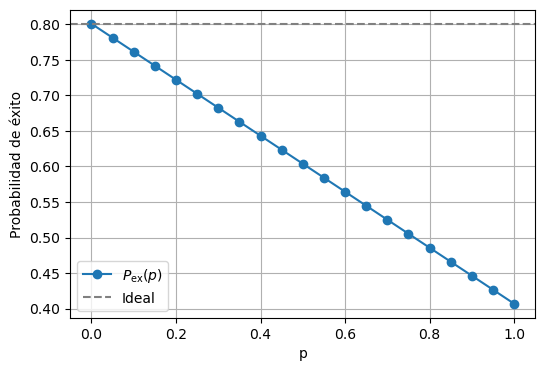

In [7]:
plt.figure(figsize=(6,4))  #Visualizamos la caida de la probabilidad de exito del algoritmo QPE con ruido
plt.plot(ps, Pex, 'o-', label=r"$P_{\mathrm{ex}}(p)$")
plt.axhline(Pex_ideal, linestyle='--', color='gray', label="Ideal")
plt.xlabel("p")
plt.ylabel("Probabilidad de éxito")
plt.legend()
plt.grid()
plt.show()


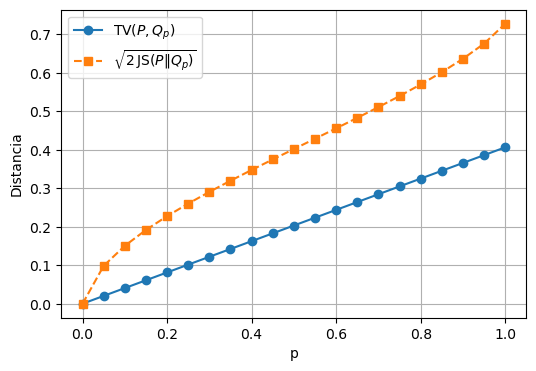

In [8]:
plt.figure(figsize=(6,4)) #Corroboraremos la desigualdad de Pinsker
plt.plot(ps, TVs, 'o-', label=r"$\mathrm{TV}(P,Q_p)$")
plt.plot(ps, np.sqrt(2*np.array(JSs)), 's--', 
         label=r"$\sqrt{2\,\mathrm{JS}(P\|Q_p)}$")
plt.xlabel("p")
plt.ylabel("Distancia")
plt.legend()
plt.grid()
plt.show()


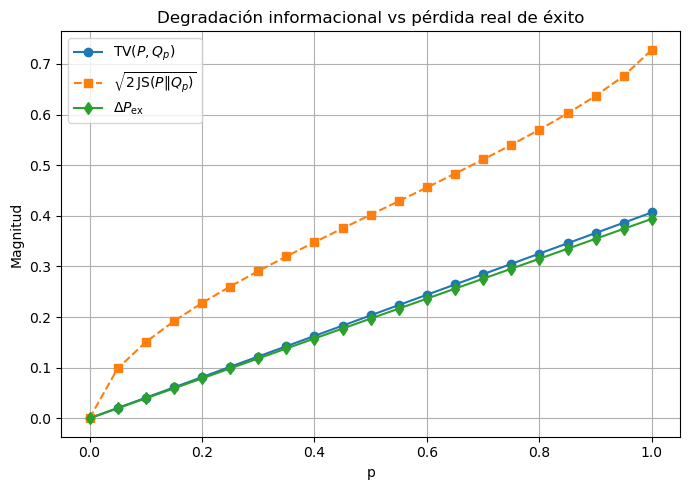

In [9]:
delta_Pex = Pex_ideal - np.array(Pex) #Perdida de la probabilidad de exito del algoritmo

plt.figure(figsize=(7,5))

plt.plot(ps, TVs, 'o-', label=r"$\mathrm{TV}(P,Q_p)$")
plt.plot(ps, np.sqrt(2*np.array(JSs)), 's--',
         label=r"$\sqrt{2\,\mathrm{JS}(P\|Q_p)}$")
plt.plot(ps, delta_Pex, 'd-', label=r"$\Delta P_{\mathrm{ex}}$")

plt.xlabel("p")
plt.ylabel("Magnitud")
plt.title("Degradación informacional vs pérdida real de éxito")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


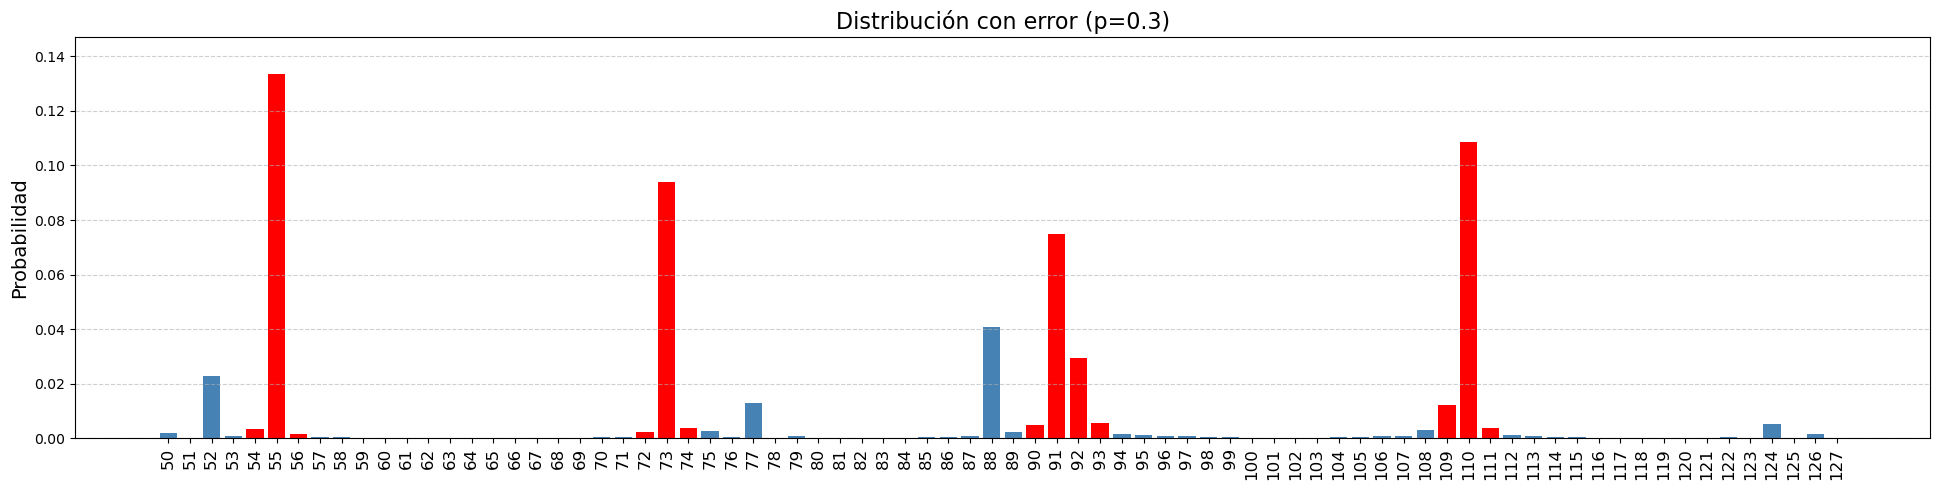

In [10]:
p_test = 0.3
Qp = noisy_distribution(P, UP, p_test)

graficar_probabilidades(
    Qp,
    titulo=f"Distribución con error (p={p_test})",
    tipo_etiqueta="num",
    ys_exitosos=ys_exitosos,
    rango=(50, 128)
)


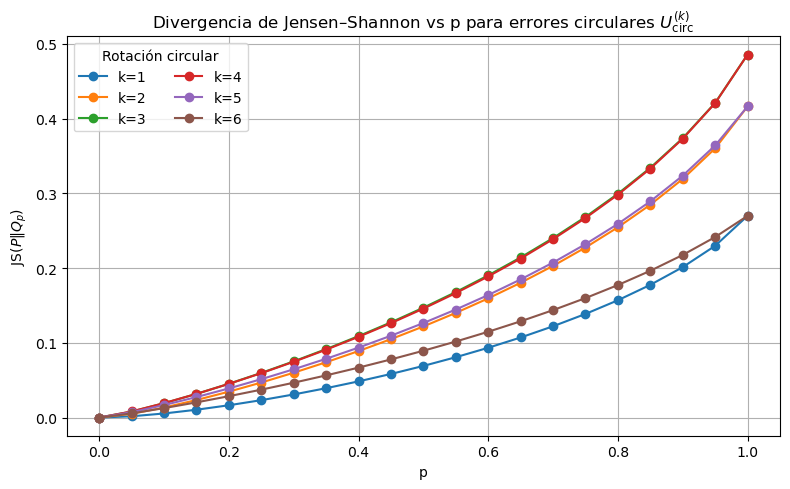

In [11]:
import numpy as np
import matplotlib.pyplot as plt

# --- Sistema base ---
r = 7
l = 7
Q = 2**l

P = probs_teoricas_QPE_l(r, l)
P = P / np.sum(P)

# Conjunto de éxito real (si lo quieres usar después; aquí no es necesario)
ys_exitosos = y_que_recuperan_r(r, l)
Pex_ideal = np.sum(P[ys_exitosos])

def noisy_distribution(P, UP, p):
    Qp = (1 - p) * P + p * UP
    return Qp / np.sum(Qp)

# --- Barrido en p ---
ps = np.linspace(0, 1, 21)

# --- Elige qué k comparar (rotaciones circulares) ---
# k=0 es identidad (JS = 0 siempre), así que lo omitimos.
ks = [1, 2, 3, 4, 5, 6]  # para l=7, estos son todos los no-triviales

plt.figure(figsize=(8, 5))

for k in ks:
    U = U_swap_circular_k(l, k)
    UP = np.real(U @ P)
    UP = UP / np.sum(UP)

    JSs = []
    for p in ps:
        Qp = noisy_distribution(P, UP, p)
        JSs.append(jensen_shannon_divergence(P, Qp, base=None))  # log natural (nats)

    plt.plot(ps, JSs, marker='o', linewidth=1.5, label=f"k={k}")

plt.xlabel("p")
plt.ylabel(r"$\mathrm{JS}(P\|Q_p)$")
plt.title("Divergencia de Jensen–Shannon vs p para errores circulares $U_{\\mathrm{circ}}^{(k)}$")
plt.grid(True)
plt.legend(title="Rotación circular", ncol=2)
plt.tight_layout()
plt.show()


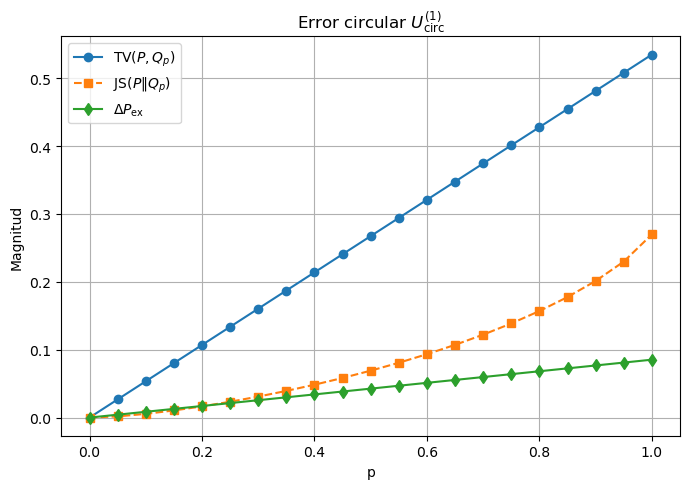

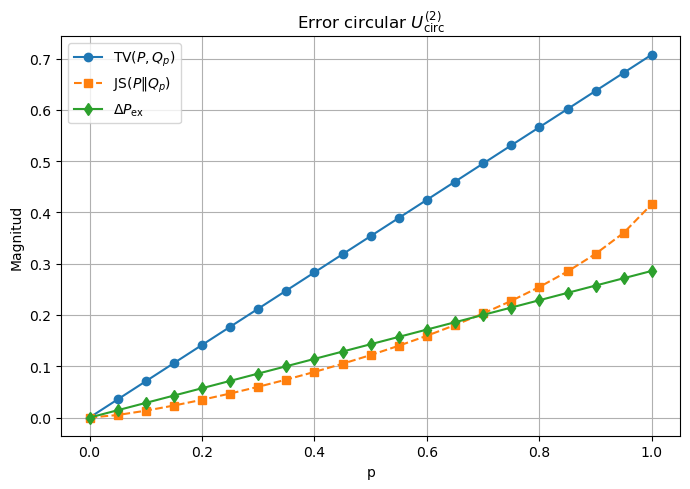

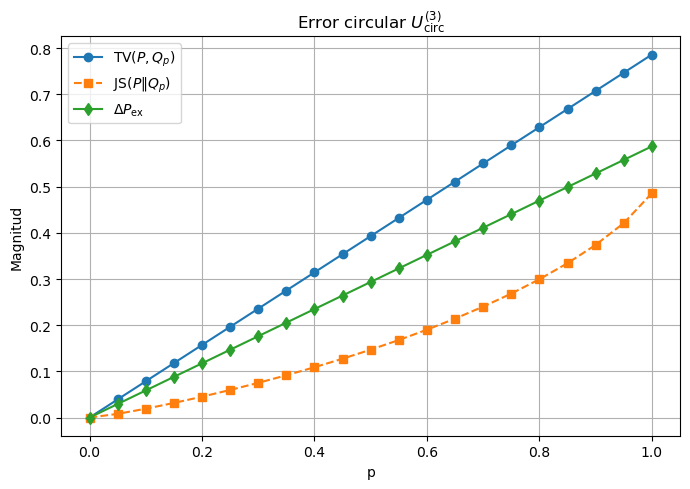

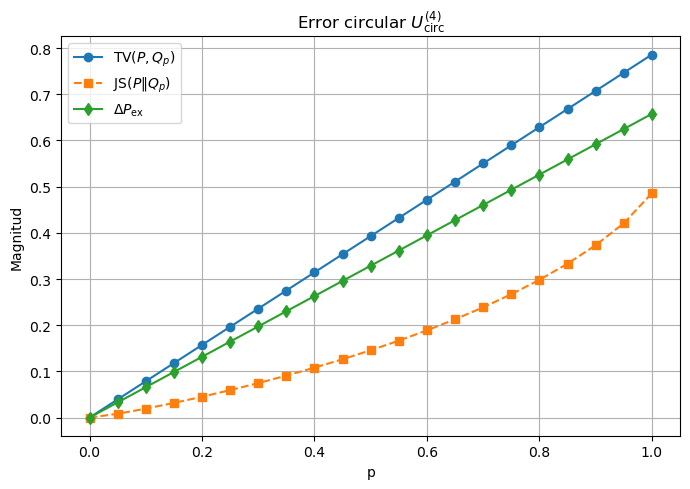

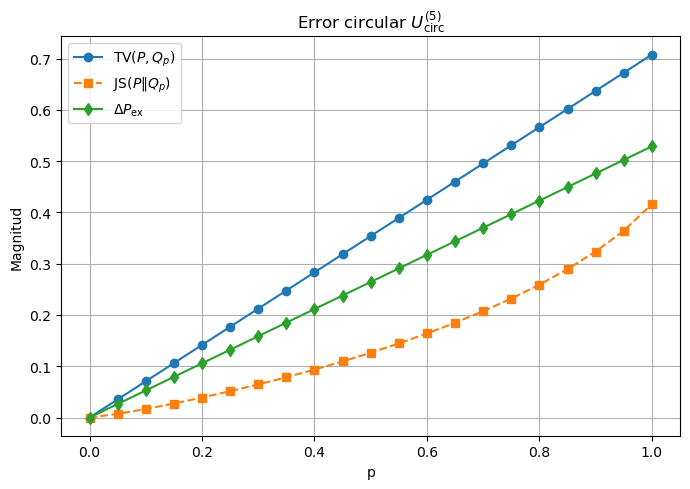

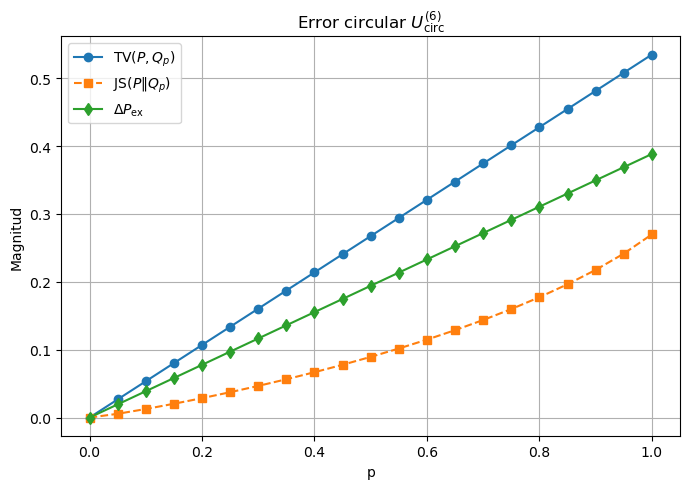

In [12]:
ks = [1, 2, 3, 4, 5, 6]  # errores circulares no triviales

for k in ks:
    U = U_swap_circular_k(l, k)
    UP = np.real(U @ P)
    UP = UP / np.sum(UP)

    TVs = []
    JSs = []
    Pex = []

    for p in ps:
        Qp = noisy_distribution(P, UP, p)

        TVs.append(total_variation_distance(P, Qp))
        JSs.append(jensen_shannon_divergence(P, Qp, base=None))  # JS pura (nats)
        Pex.append(np.sum(Qp[ys_exitosos]))

    TVs = np.array(TVs)
    JSs = np.array(JSs)
    Pex = np.array(Pex)
    delta_Pex = Pex_ideal - Pex

    # --- Gráfica ---
    plt.figure(figsize=(7, 5))
    plt.plot(ps, TVs, 'o-', label=r"$\mathrm{TV}(P,Q_p)$")
    plt.plot(ps, JSs, 's--', label=r"$\mathrm{JS}(P\|Q_p)$")
    plt.plot(ps, delta_Pex, 'd-', label=r"$\Delta P_{\mathrm{ex}}$")

    plt.xlabel("p")
    plt.ylabel("Magnitud")
    plt.title(f"Error circular $U_{{\\mathrm{{circ}}}}^{{({k})}}$")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()


Los puntos para seguir avanzando en este problema son los siguientes:

<!-- 1- Los picos de la QPE se encuentran en valores aproximados $y=\frac{k*2^l}{r}$. Quiero ver para los valores enteros mas cercanos a esos valores, y si existe algun patron que sirva para poder encontrarlo y asi predecir que errores seran mas destructivos o no -->

2- Estudiar la invariancia de los SWAP en el sistema. Es decir, que valores no se ven afectados por las permutaciones, por que, y como y ver como conectar esto con la distribución de los picos. Por combinatoria, un swap entre 2 qubits altera a la mitad de los valores. ¿Que patron siguen?

3- Quiero ver si combinando estos patrones puedo encontrar una forma de modelar con alguno de los valores de información cuántica este error. Ahora solo hemos encontrado una cota y una forma de visualizar la información, mas no una relación directa